# Лабораторная работа E7 — Классификация: вектор признаков в номер жеста

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/e7.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/e7.html)**.

**Что разбираем.** В E6 мы превратили окно сигнала в вектор из 56 чисел и
увидели, что жесты в этом пространстве расходятся. Теперь заставим машину
проводить границы между ними: обучим классификатор и посмотрим, на чём он
ошибается.

Главное правило работы: **учим на одной серии, проверяем на другой**. У
каждого испытуемого в датасете две записи, сделанные подряд. Если проверять
на тех же окнах, на которых учились, точность получится завышенной — это
отдельная тема лабы E8.

Сравним три линейных классификатора: LDA, логистическую регрессию и линейный
SVM. Все три проводят прямые границы, различается только критерий, по
которому они эти границы выбирают.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


In [2]:
ensure([("sklearn", "scikit-learn")])

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

Готово. Python 3.10.12


In [3]:
# ЯЧЕЙКА 2 · Признаки ЭМГ и нарезка на окна.
# Это «чёрный ящик» лабы: запусти один раз и дальше просто вызывай функции.
# Внутри — классический набор Хадгинса (Hudgins et al., 1993) плюс две
# частотные характеристики. Разбираться в реализации не нужно.

FS = 1000.0          # частота дискретизации записи, Гц
N_CH = 8             # каналов в браслете

TD_NAMES = ["MAV", "RMS", "WL", "ZC", "SSC"]
FREQ_NAMES = ["MDF", "MNF"]


def window_signal(X, y, fs=FS, win_ms=200.0, step_ms=100.0, keep=None, purity=0.6):
    """Режет запись X[N, C] с метками y[N] на скользящие окна.

    Метка окна — самый частый класс внутри него. Окно на стыке двух жестов
    (ни один класс не занимает purity доли окна) выбрасывается.
    Возвращает (windows[K, W, C], labels[K]).
    """
    width = int(round(win_ms / 1000.0 * fs))
    step = int(round(step_ms / 1000.0 * fs))
    keep = set(range(1, 8)) if keep is None else set(keep)
    wins, labs = [], []
    for start in range(0, len(X) - width + 1, step):
        chunk = y[start:start + width]
        values, counts = np.unique(chunk, return_counts=True)
        label = int(values[np.argmax(counts)])
        if label not in keep or counts.max() < purity * width:
            continue
        wins.append(X[start:start + width, :])
        labs.append(label)
    if not wins:
        return np.empty((0, width, X.shape[1])), np.empty((0,), int)
    return np.asarray(wins), np.asarray(labs, int)


def td_features(x, rel_eps=0.02):
    """Пять признаков Хадгинса по одному каналу.

    MAV — средний модуль (насколько сильно напряжена мышца);
    RMS — эффективная амплитуда (то же, что в лабе E4);
    WL  — суммарная длина кривой, мера «изрезанности»;
    ZC  — сколько раз сигнал пересёк ноль (грубая оценка частоты);
    SSC — сколько раз сменился знак наклона (тоже про частоту).

    ZC и SSC считают с мёртвой зоной rel_eps от уровня сигнала: без неё они
    считали бы дрожание нуля, а не настоящие колебания.
    """
    eps = rel_eps * np.sqrt(np.mean(x ** 2)) + 1e-12
    diff = np.diff(x)
    zc = int(np.sum((x[:-1] * x[1:] < 0) & (np.abs(diff) > eps)))
    d1, d2 = x[1:-1] - x[:-2], x[1:-1] - x[2:]
    ssc = int(np.sum((d1 * d2 > 0) & ((np.abs(d1) > eps) | (np.abs(d2) > eps))))
    return np.array([np.mean(np.abs(x)), np.sqrt(np.mean(x ** 2)),
                     np.sum(np.abs(diff)), zc, ssc], float)


def freq_features(x, fs=FS):
    """MDF и MNF — медианная и средняя частоты спектра мощности канала.

    MDF делит энергию спектра пополам, MNF — центр масс спектра. Обе падают
    при утомлении мышцы, поэтому их считают вместе с амплитудными.
    """
    x = x - np.mean(x)
    power = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    total = power.sum() + 1e-24
    cumulative = np.cumsum(power)
    mdf = freqs[np.searchsorted(cumulative, cumulative[-1] / 2)]
    return np.array([mdf, np.sum(freqs * power) / total], float)


def features_window(win, fs=FS):
    """Одно окно win[W, C] → один длинный вектор чисел: 7 признаков на канал."""
    return np.concatenate([
        np.concatenate([td_features(win[:, c]), freq_features(win[:, c], fs)])
        for c in range(win.shape[1])])


def feature_names(n_ch=N_CH):
    """Имена координат вектора признаков — в том же порядке, что и значения."""
    return ["ch%d_%s" % (c + 1, nm)
            for c in range(n_ch) for nm in TD_NAMES + FREQ_NAMES]


def features_of(X, y, fs=FS, win_ms=200.0, step_ms=100.0, keep=None):
    """Запись → матрица признаков. Возвращает (Xf[K, D], labels[K])."""
    wins, labs = window_signal(X, y, fs, win_ms, step_ms, keep)
    return np.array([features_window(w, fs) for w in wins]), labs

In [4]:
# ЯЧЕЙКА 3 · Данные: скачиваем настоящий датасет.
# Работаем не на выдумке, а на открытой записи UCI «EMG Data for Gestures»
# (Lobov et al., 2018): 36 человек, браслет MYO — восемь электродов по
# окружности предплечья, по две серии на человека, размеченные жесты.
# Архив ~17 МБ, качается один раз за сессию. Ничего ставить руками не нужно.

import os
import glob
import urllib.request
import zipfile

DATA_URL = "https://archive.ics.uci.edu/static/public/481/emg+data+for+gestures.zip"
DATA_DIR = "EMG_data_for_gestures-master"

GESTURE_NAMES = {
    0: "неразмечено", 1: "покой", 2: "кулак", 3: "сгибание",
    4: "разгибание", 5: "радиальное", 6: "локтевое", 7: "ладонь",
}


def fetch_dataset(url=DATA_URL, directory=DATA_DIR):
    """Скачивает и распаковывает датасет. Повторный вызов ничего не делает."""
    # Печатаем только имя папки, без полного пути: путь на чужой машине
    # читателю ничего не говорит, а в сохранённом выводе ноутбука остаётся.
    directory = os.environ.get("EMG_DATA_DIR", directory)
    name = os.path.basename(directory.rstrip("/\\")) or directory
    if os.path.isdir(directory):
        print("Датасет уже на месте:", name)
        return directory
    print("Скачиваю архив (~17 МБ)...")
    archive, _ = urllib.request.urlretrieve(url)
    with zipfile.ZipFile(archive) as zf:
        zf.extractall(".")
    os.remove(archive)
    print("Готово:", name)
    return directory


def list_subjects(directory=DATA_DIR):
    """Номера доступных испытуемых: '01', '02', ... '36'."""
    return sorted(d for d in os.listdir(directory)
                  if d.isdigit() and os.path.isdir(os.path.join(directory, d)))


def subject_files(subject, directory=DATA_DIR):
    """Файлы одного человека — обычно две серии, записанные подряд."""
    pattern = os.path.join(directory, str(subject).zfill(2), "*_raw_data_*.txt")
    return sorted(glob.glob(pattern))


def load_record(path):
    """Один файл записи → (X[N, 8], y[N]).

    В файле десять столбцов: время в мс, восемь каналов и метка жеста.
    Шаг времени 1 мс, отсюда FS = 1000 Гц. Метка 0 — участок без разметки.
    Каналы переводим из вольт в милливольты, иначе все числа выглядят как
    0.00002 и читать их невозможно.
    """
    data = np.loadtxt(path, skiprows=1)
    return data[:, 1:9] * 1000.0, data[:, 9].astype(int)


def plot_record(X, y, fs=FS, seconds=12.0, channels=(0, 2, 4, 6)):
    """Кусок записи: как выглядят каналы и где какой жест был размечен."""
    n = min(len(X), int(seconds * fs))
    t = np.arange(n) / fs
    present = sorted(set(int(v) for v in np.unique(y[:n])))
    fig, axes = plt.subplots(len(channels) + 1, 1, sharex=True,
                             figsize=(12, 1.4 * len(channels) + 2.4))
    for ax, c in zip(axes, channels):
        ax.plot(t, X[:n, c], lw=0.6, color="steelblue")
        ax.set_ylabel("кан. %d" % (c + 1))
    axes[-1].step(t, y[:n], where="post", color="darkorange", lw=1.6)
    axes[-1].set(xlabel="$t$, с", ylabel="жест", yticks=present)
    axes[-1].set_yticklabels([GESTURE_NAMES[v] for v in present])
    axes[0].set_title("Запись браслета MYO: четыре канала из восьми и разметка жестов")
    fig.tight_layout()
    plt.show()


def class_table(y, title="Распределение по классам"):
    """Сколько окон (или отсчётов) пришлось на каждый класс."""
    values, counts = np.unique(y, return_counts=True)
    print(title + ":")
    for v, c in zip(values, counts):
        print("   %-12s %6d" % (GESTURE_NAMES[int(v)], c))

In [5]:
# ЯЧЕЙКА · Матрица ошибок: печать и картинка.
# Тоже «чёрный ящик»: запусти один раз, дальше просто вызывай.

def confusion(y_true, y_pred, labels):
    """Матрица ошибок вручную: строки — истина, столбцы — предсказание."""
    index = {int(l): i for i, l in enumerate(labels)}
    matrix = np.zeros((len(labels), len(labels)), int)
    for t, p in zip(y_true, y_pred):
        matrix[index[int(t)], index[int(p)]] += 1
    return matrix


def accuracy(y_true, y_pred):
    """Доля верно угаданных окон."""
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


def print_confusion(matrix, labels, title="Матрица ошибок"):
    """Та же матрица текстом, в процентах по строкам."""
    names = [GESTURE_NAMES[int(l)] for l in labels]
    print(title + " (%, строка — истина):")
    print("   %-12s" % "" + "".join("%9s" % n[:8] for n in names))
    for name, row in zip(names, matrix):
        total = row.sum() + 1e-12
        print("   %-12s" % name[:12] + "".join("%9.1f" % (100.0 * v / total) for v in row))


def plot_confusion(matrix, labels, title="Матрица ошибок"):
    """Картинка матрицы: по диагонали — верные ответы, вне её — путаница."""
    names = [GESTURE_NAMES[int(l)] for l in labels]
    share = matrix / (matrix.sum(axis=1, keepdims=True) + 1e-12)
    fig, ax = plt.subplots(figsize=(1.0 + 1.1 * len(labels), 0.9 + 1.0 * len(labels)))
    image = ax.imshow(share, cmap="Blues", vmin=0, vmax=1)
    ax.set(xticks=range(len(labels)), yticks=range(len(labels)),
           xlabel="предсказано", ylabel="истина", title=title)
    ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9)
    ax.set_yticklabels(names, fontsize=9)
    ax.grid(False)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, "%d" % matrix[i, j], ha="center", va="center", fontsize=9,
                    color="white" if share[i, j] > 0.5 else "black")
    fig.colorbar(image, ax=ax, fraction=0.045, label="доля строки")
    fig.tight_layout()
    plt.show()

## Ячейка 5 · Две серии одного человека: обучающая и проверочная

Первая запись идёт на обучение, вторая — на проверку. Ни одно окно не
попадает в обе выборки.

In [6]:
WIN_MS = 200.0
STEP_MS = 50.0
GESTURES = [1, 2, 3, 4]         # покой, кулак, сгибание, разгибание

root = fetch_dataset()
files = subject_files("01", root)

Xtr, ytr = features_of(*load_record(files[0]), fs=FS, win_ms=WIN_MS,
                       step_ms=STEP_MS, keep=GESTURES)
Xte, yte = features_of(*load_record(files[1]), fs=FS, win_ms=WIN_MS,
                       step_ms=STEP_MS, keep=GESTURES)

print("Обучающих окон: %d, проверочных: %d, признаков в окне: %d"
      % (len(ytr), len(yte), Xtr.shape[1]))
class_table(ytr, "Обучающая выборка")
class_table(yte, "Проверочная выборка")

Датасет уже на месте: EMG_data_for_gestures-master


Обучающих окон: 285, проверочных: 269, признаков в окне: 56
Обучающая выборка:
   покой            73
   кулак            69
   сгибание         75
   разгибание       68
Проверочная выборка:
   покой            69
   кулак            64
   сгибание         70
   разгибание       66


## Ячейка 6 · Три классификатора на одних и тех же данных

`StandardScaler` перед каждым — обязателен: WL измеряется сотнями, а ZC
единицами, и без выравнивания масштабов признак с большими числами задавит
остальные.

In [7]:
MODELS = {
    "LDA": make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()),
    "Логистическая регрессия": make_pipeline(StandardScaler(),
                                             LogisticRegression(max_iter=2000)),
    "Линейный SVM": make_pipeline(StandardScaler(), LinearSVC(C=1.0)),
}

scores = {}
for name, model in MODELS.items():
    model.fit(Xtr, ytr)
    predicted = model.predict(Xte)
    scores[name] = accuracy(yte, predicted)
    print("%-24s точность на проверочной серии = %.3f" % (name, scores[name]))

print("\nСлучайное угадывание дало бы %.3f (1 из %d классов)."
      % (1.0 / len(GESTURES), len(GESTURES)))

LDA                      точность на проверочной серии = 0.926
Логистическая регрессия  точность на проверочной серии = 0.963
Линейный SVM             точность на проверочной серии = 0.978

Случайное угадывание дало бы 0.250 (1 из 4 классов).


## Ячейка 7 · Где именно классификатор путается

Точность одним числом ничего не объясняет. Матрица ошибок показывает, какой
жест с каким сливается: строка — что было на самом деле, столбец — что
ответила машина.

Лучший классификатор: Линейный SVM (точность 0.978)

Матрица ошибок (%, строка — истина):
                   покой    кулак сгибание разгибан
   покой           100.0      0.0      0.0      0.0
   кулак             7.8     92.2      0.0      0.0
   сгибание          1.4      0.0     98.6      0.0
   разгибание        0.0      0.0      0.0    100.0

Чаще всего «кулак» принимают за «покой»: 5 окон.


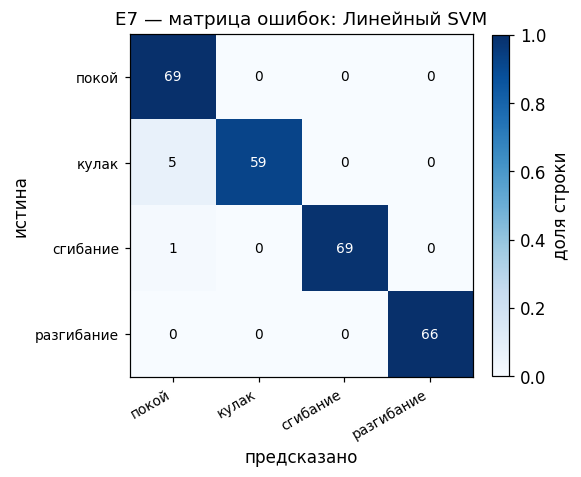

In [8]:
best = max(scores, key=scores.get)
predicted = MODELS[best].predict(Xte)
matrix = confusion(yte, predicted, GESTURES)

print("Лучший классификатор: %s (точность %.3f)\n" % (best, scores[best]))
print_confusion(matrix, GESTURES)

errors = [(GESTURE_NAMES[GESTURES[i]], GESTURE_NAMES[GESTURES[j]], matrix[i, j])
          for i in range(len(GESTURES)) for j in range(len(GESTURES)) if i != j]
worst = max(errors, key=lambda e: e[2])
print("\nЧаще всего «%s» принимают за «%s»: %d окон." % worst)

plot_confusion(matrix, GESTURES, "E7 — матрица ошибок: %s" % best)

Диагональ — верные ответы. Всё, что вне её, — конкретная пара жестов,
которую признаки не различают; чинить это надо в E6, добавляя признаки, а не
перебирая классификаторы.

## Задания

1. Возьми набор жестов из своего варианта, приведи точность всех трёх
   классификаторов и матрицу ошибок лучшего.
2. Замени проверку на случайный сплит внутри первой серии
   (`Xtr`/`ytr` пополам). Насколько выросла точность и почему такой
   результат нельзя показывать как настоящий?
3. Убери из вектора признаков MDF и MNF (правь `features_window`) и повтори.
   Что происходит с точностью и с матрицей ошибок?